In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\allpe\AppData\Local\Temp\ipykernel_16976\2279782395.py:21: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt((2/3)*k)/U(z,u_star,z0)


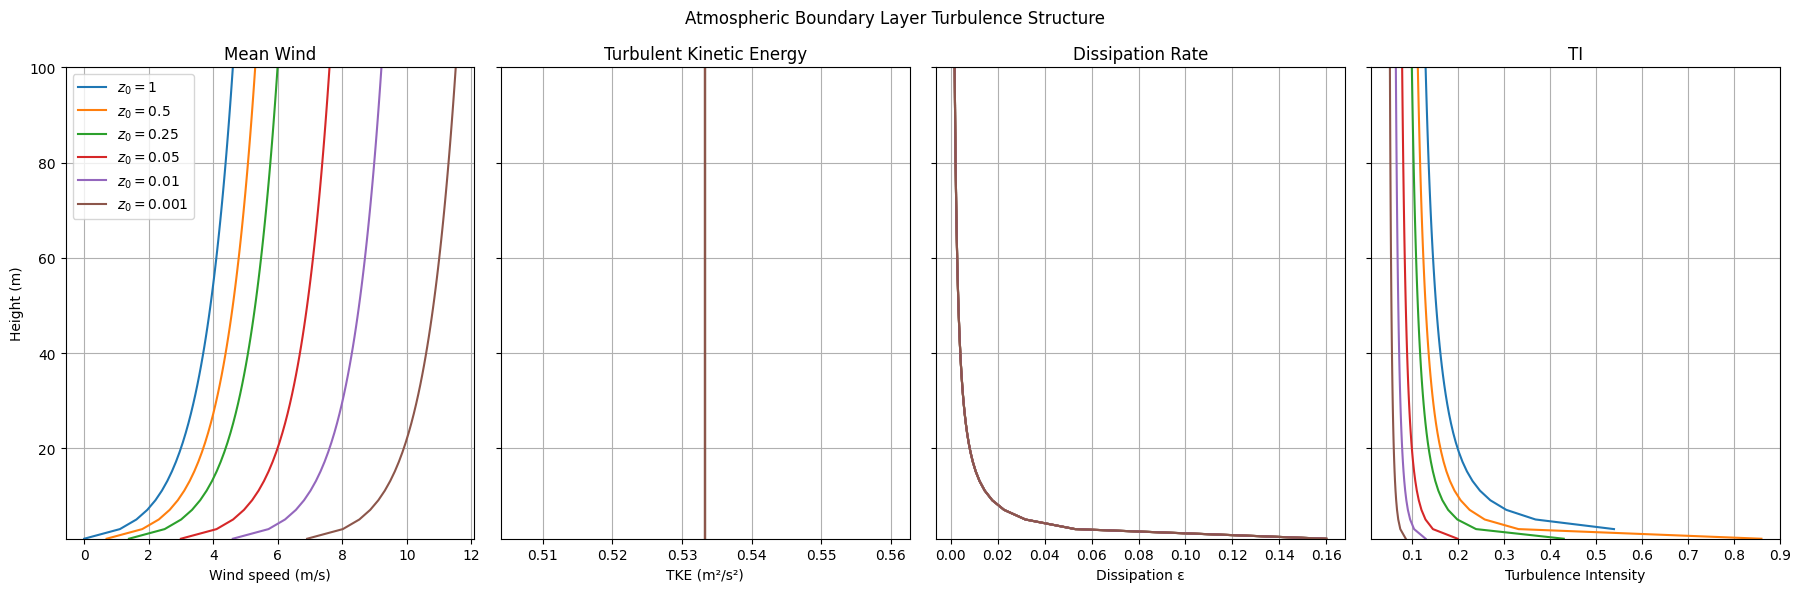

In [7]:
# constants
kappa = 0.4
Cmu = 0.09
u_star = 0.4

# surface roughness
z0 = [1,0.5,0.25,0.05,0.01,0.001]


def U(z,u_star,z0):
    return (u_star/kappa)*np.log(z/z0)

def k_tke(u_star):
    return (u_star**2)/np.sqrt(Cmu)

def epsilon(z,u_star):
    return (u_star**3)/(kappa*z)

def TI(z,u_star,z0):
    k = k_tke(u_star)
    return np.sqrt((2/3)*k)/U(z,u_star,z0)

z = np.linspace(1,100)

fig,ax = plt.subplots(1,4,figsize=(18,6),sharey=True)

for rough in z0:

    ax[0].plot(U(z,u_star,rough),z,label=f'$z_0={rough}$')
    ax[1].plot(np.ones_like(z)*k_tke(u_star),z)
    ax[2].plot(epsilon(z,u_star),z)
    ax[3].plot(TI(z,u_star,rough),z)

ax[0].set_xlabel("Wind speed (m/s)")
ax[0].set_title("Mean Wind")

ax[1].set_xlabel("TKE (m²/s²)")
ax[1].set_title("Turbulent Kinetic Energy")

ax[2].set_xlabel("Dissipation ε")
ax[2].set_title("Dissipation Rate")

ax[3].set_xlabel("Turbulence Intensity")
ax[3].set_title("TI")

ax[0].set_ylabel("Height (m)")

for a in ax:
    a.grid(True)
    a.set_ylim(1,100)

ax[0].legend()

plt.suptitle("Atmospheric Boundary Layer Turbulence Structure")

plt.tight_layout()
plt.show()

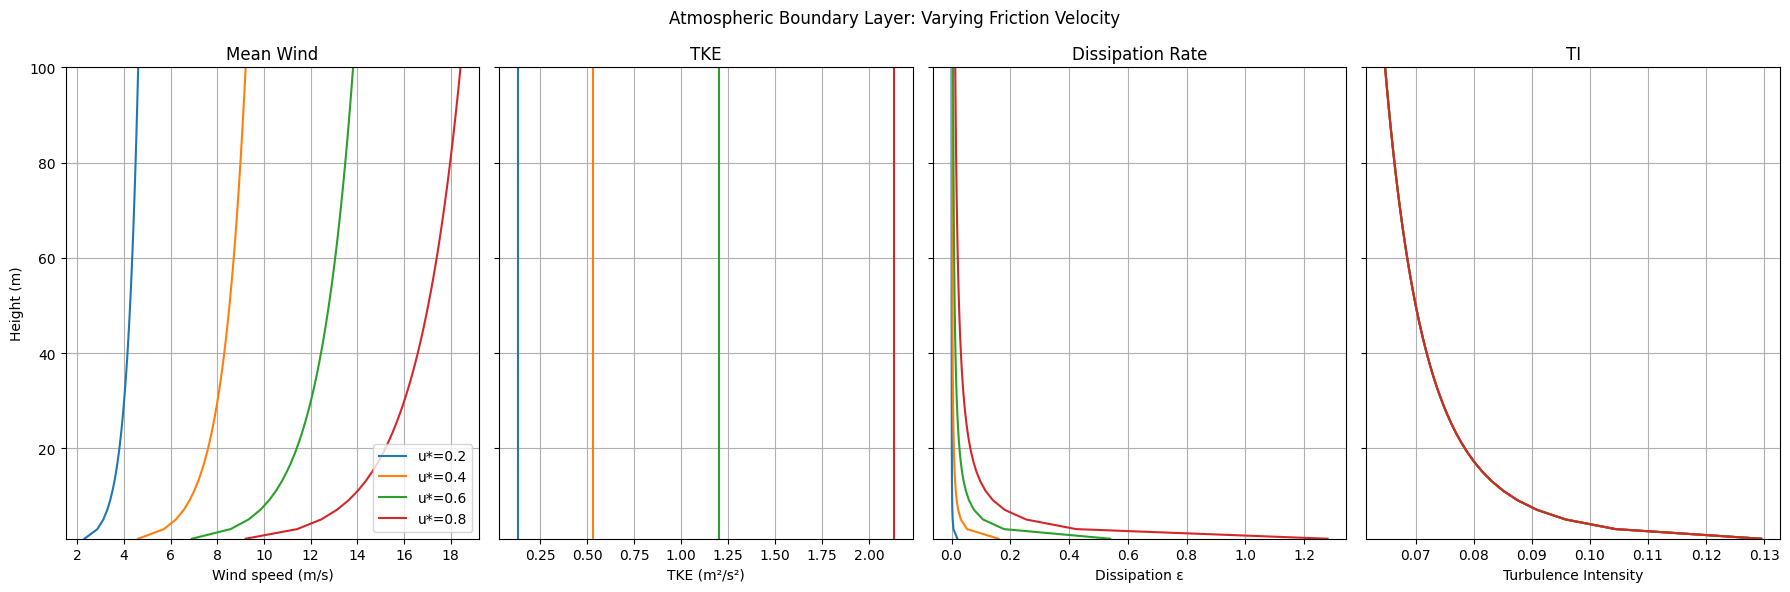

In [8]:
# constants
kappa = 0.4
Cmu = 0.09
z0 = 0.01  # fixed roughness

def U(z,u_star):
    return (u_star/kappa)*np.log(z/z0)

def k_tke(u_star):
    return u_star**2/np.sqrt(Cmu)

def epsilon(z,u_star):
    return u_star**3/(kappa*z)

def TI(z,u_star):
    k = k_tke(u_star)
    return np.sqrt(2/3 * k)/U(z,u_star)

z = np.linspace(1,100)

u_star_values = [0.2, 0.4, 0.6, 0.8]

fig, ax = plt.subplots(1,4,figsize=(18,6), sharey=True)

for u_star in u_star_values:
    ax[0].plot(U(z,u_star), z, label=f'u*={u_star}')
    ax[1].plot(np.ones_like(z)*k_tke(u_star), z)
    ax[2].plot(epsilon(z,u_star), z)
    ax[3].plot(TI(z,u_star), z)

ax[0].set_xlabel("Wind speed (m/s)")
ax[0].set_title("Mean Wind")
ax[0].legend()

ax[1].set_xlabel("TKE (m²/s²)")
ax[1].set_title("TKE")

ax[2].set_xlabel("Dissipation ε")
ax[2].set_title("Dissipation Rate")

ax[3].set_xlabel("Turbulence Intensity")
ax[3].set_title("TI")

ax[0].set_ylabel("Height (m)")

for a in ax:
    a.grid(True)
    a.set_ylim(1,100)

plt.suptitle("Atmospheric Boundary Layer: Varying Friction Velocity")
plt.tight_layout()
plt.show()

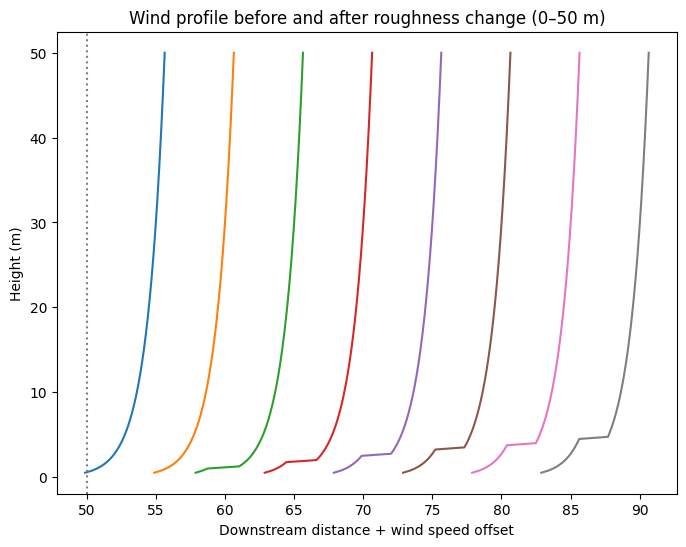

In [33]:
# constants
kappa = 0.4
ustar = 0.5

# roughness lengths
z0_up = 0.01
z0_down = 0.05

# vertical grid (0–50 m)
z = np.linspace(0.5,50,200)

# domain
x_domain = 100
x_change = x_domain/2

# locations of profiles
x_positions = [x_change-5, x_change, x_change+5,x_change+10, x_change+15, x_change+20, x_change+25, x_change+30]

# internal boundary layer growth
def ibl_height(x):
    
    dx = x - x_change
    
    if dx <= 0:
        return 0
    else:
        return 0.3 * dx**0.8


# wind profile
def wind_profile(z,x):

    delta = ibl_height(x)
    U = np.zeros_like(z)

    for i in range(len(z)):

        # upstream of roughness change
        if x <= x_change:
            U[i] = (ustar/kappa)*np.log(z[i]/z0_up)

        # downstream region
        else:
            if z[i] < delta:
                U[i] = (ustar/kappa)*np.log(z[i]/z0_down)
            else:
                U[i] = (ustar/kappa)*np.log(z[i]/z0_up)

    return U


plt.figure(figsize=(8,6))

for x in x_positions:

    U = wind_profile(z,x)

    # shift profile to x location
    plt.plot(x + U, z)


# internal boundary layer
x_line = np.linspace(0,x_domain,200)
ibl = [ibl_height(x) for x in x_line]

#plt.plot(x_line, ibl, 'k--', label="Internal BL")

# mark roughness change
plt.axvline(x_change, color='gray', linestyle=':')

plt.xlabel("Downstream distance + wind speed offset")
plt.ylabel("Height (m)")
plt.title("Wind profile before and after roughness change (0–50 m)")
#plt.legend()

plt.show()